# Hi-Five — Train the XGBoost ASL Alphabet Model

Trains the XGBoost classifier from `data/landmarks.csv` (produced by
`python -m src.extract_features`) and saves the result to
`models/asl_xgb.json` and `models/label_encoder.pkl`.

**Run cells top to bottom.** You can rerun the training cell with
different hyperparameters without reloading the CSV.

This notebook expects to be run from the `ml/` directory.

In [4]:
# Imports
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# 63 features = 21 landmarks × (x, y, z)
FEATURE_DIM = 63

# Where to read from / write to
CSV_PATH = Path("../data/landmarks.csv")
OUT_DIR = Path("../models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibility
RANDOM_STATE = 42

print(f"CSV:    {CSV_PATH}")
print(f"Models: {OUT_DIR}")

CSV:    ..\data\landmarks.csv
Models: ..\models


## 1. Load the landmarks CSV

Reads the CSV produced by `extract_features.py`. Each row is one image:
63 normalized landmark features + the class label.

In [5]:
# Load the landmarks CSV
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} samples")
df.head()

Loaded 63,579 samples


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,...,f55,f56,f57,f58,f59,f60,f61,f62,label,source_image
0,0.0,0.0,0.0,0.619197,-0.354230,-0.149811,0.963929,-0.981060,-0.207981,1.074976,...,-1.311579,-0.525416,-0.245486,-0.895916,-0.478351,-0.236962,-0.632824,-0.362865,A,A/A1.jpg
1,0.0,0.0,0.0,0.586609,-0.335769,-0.172014,0.989698,-0.996148,-0.251375,1.110982,...,-1.300734,-0.579254,-0.237317,-0.876762,-0.531334,-0.247779,-0.628266,-0.433275,A,A/A10.jpg
2,0.0,0.0,0.0,0.548797,-0.341131,-0.177712,0.862279,-1.021873,-0.226612,0.921131,...,-1.343471,-0.471312,-0.503788,-0.989694,-0.446869,-0.445758,-0.695766,-0.350514,A,A/A1000.jpg
3,0.0,0.0,0.0,0.607779,-0.353540,-0.152488,0.914818,-0.967453,-0.218817,0.896753,...,-1.170995,-0.491547,-0.111546,-0.829107,-0.477528,-0.088690,-0.606895,-0.410985,A,A/A1001.jpg
4,0.0,0.0,0.0,0.596144,-0.334466,-0.161452,0.908711,-0.944051,-0.228029,0.919187,...,-1.186124,-0.481719,-0.099689,-0.838737,-0.479029,-0.074905,-0.599539,-0.415474,A,A/A1002.jpg


28 classes total



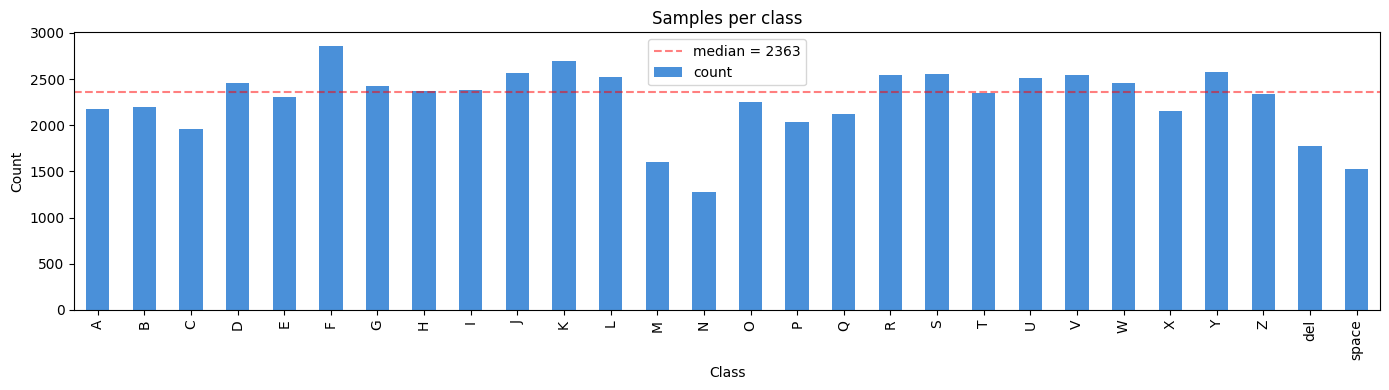

label
A        2182
B        2202
C        1962
D        2457
E        2307
F        2864
G        2428
H        2373
I        2379
J        2571
K        2699
L        2521
M        1603
N        1275
O        2258
P        2040
Q        2118
R        2545
S        2555
T        2354
U        2509
V        2548
W        2453
X        2156
Y        2580
Z        2343
del      1773
space    1524
Name: count, dtype: int64

In [6]:
# Class distribution — how many samples per letter?
class_counts = df["label"].value_counts().sort_index()
print(f"{len(class_counts)} classes total\n")

fig, ax = plt.subplots(figsize=(14, 4))
class_counts.plot(kind="bar", ax=ax, color="#4a90d9")
ax.set_title("Samples per class")
ax.set_xlabel("Class")
ax.set_ylabel("Count")
ax.axhline(class_counts.median(), color="red", linestyle="--", alpha=0.5,
           label=f"median = {int(class_counts.median())}")
ax.legend()
plt.tight_layout()
plt.show()

class_counts

## 2. Encode labels and split train/test

XGBoost needs integer labels, so we use `LabelEncoder` to translate
`A`, `B`, `C`, ... → `0`, `1`, `2`, ...

We do an 80/20 stratified split — "stratified" means each class keeps
roughly the same proportion in both the training set and the test set.

In [7]:
# Build feature matrix X and label vector y
feature_cols = [f"f{i}" for i in range(FEATURE_DIM)]
X = df[feature_cols].to_numpy(dtype=np.float32)
y_str = df["label"].to_numpy()

# Encode labels: "A" -> 0, "B" -> 1, ...
le = LabelEncoder()
y = le.fit_transform(y_str)

# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print(f"X_train: {X_train.shape}  X_test: {X_test.shape}")
print(f"Classes: {list(le.classes_)}")

X_train: (50863, 63)  X_test: (12716, 63)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'space']


## 3. Hyperparameters

You can edit this cell and re-run the training cell below without
reloading the CSV — that's the main reason to be in a notebook
instead of running `train.py`.

Defaults match `train.py` and are based on the reference repo
(98.43% accuracy). Sensible knobs to try:
- `n_estimators` — more trees → better fit, slower train. 100–500 is the useful range.
- `max_depth` — deeper trees → more complex patterns, more risk of overfitting. 4–8 is normal.
- `learning_rate` — smaller → needs more trees but generalizes better. 0.05–0.3 is normal.

In [8]:
# Hyperparameters
params = dict(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
)

# For a quick sanity check during experimentation, swap to:
# params = dict(n_estimators=50, max_depth=4, learning_rate=0.3)

params

{'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.1}

## 4. Train the model

This is the slow cell — usually 1–3 minutes on the full dataset.

`tree_method="hist"` is the fast CPU-friendly variant and is what
XGBoost recommends for tabular data of this size.

In [9]:
# Train
clf = XGBClassifier(
    objective="multi:softprob",
    num_class=len(le.classes_),
    tree_method="hist",
    n_jobs=-1,
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    **params,
)

clf.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)
print("Training complete.")

Training complete.


## 5. Evaluate

Test accuracy + per-class precision/recall/F1. The reference repo
reports 98.43% — anywhere in the 97–99% range is healthy.

In [10]:
# Evaluate on the held-out test set
y_pred = clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc * 100:.2f}%\n")

print("Classification report:")
print(classification_report(
    y_test, y_pred,
    target_names=le.classes_,
    digits=3,
))

Test accuracy: 98.66%

Classification report:
              precision    recall  f1-score   support

           A      0.989     0.991     0.990       436
           B      0.991     0.998     0.994       440
           C      0.987     1.000     0.994       392
           D      0.994     0.986     0.990       491
           E      0.996     0.993     0.995       461
           F      0.997     0.995     0.996       573
           G      0.986     0.992     0.989       486
           H      0.987     0.983     0.985       475
           I      0.989     0.975     0.982       476
           J      0.988     0.992     0.990       514
           K      0.996     0.987     0.992       540
           L      0.992     0.998     0.995       504
           M      0.918     0.975     0.945       320
           N      0.967     0.906     0.935       255
           O      0.987     0.987     0.987       452
           P      0.993     0.985     0.989       408
           Q      0.991     0.986  

## 6. Confusion matrix

Rows = true label, columns = predicted label. A perfect model has
all its weight on the diagonal. The interesting cells are the
off-diagonal ones — those tell you which letters the model
confuses with which.

Expected hard cases (the reference repo found the same):
- **M ↔ N** — both fists with thumb tucked, geometrically similar
- **A ↔ S** — both fists with thumb visible, similar pose
- **U ↔ V** — both two fingers up, distinguished only by spread

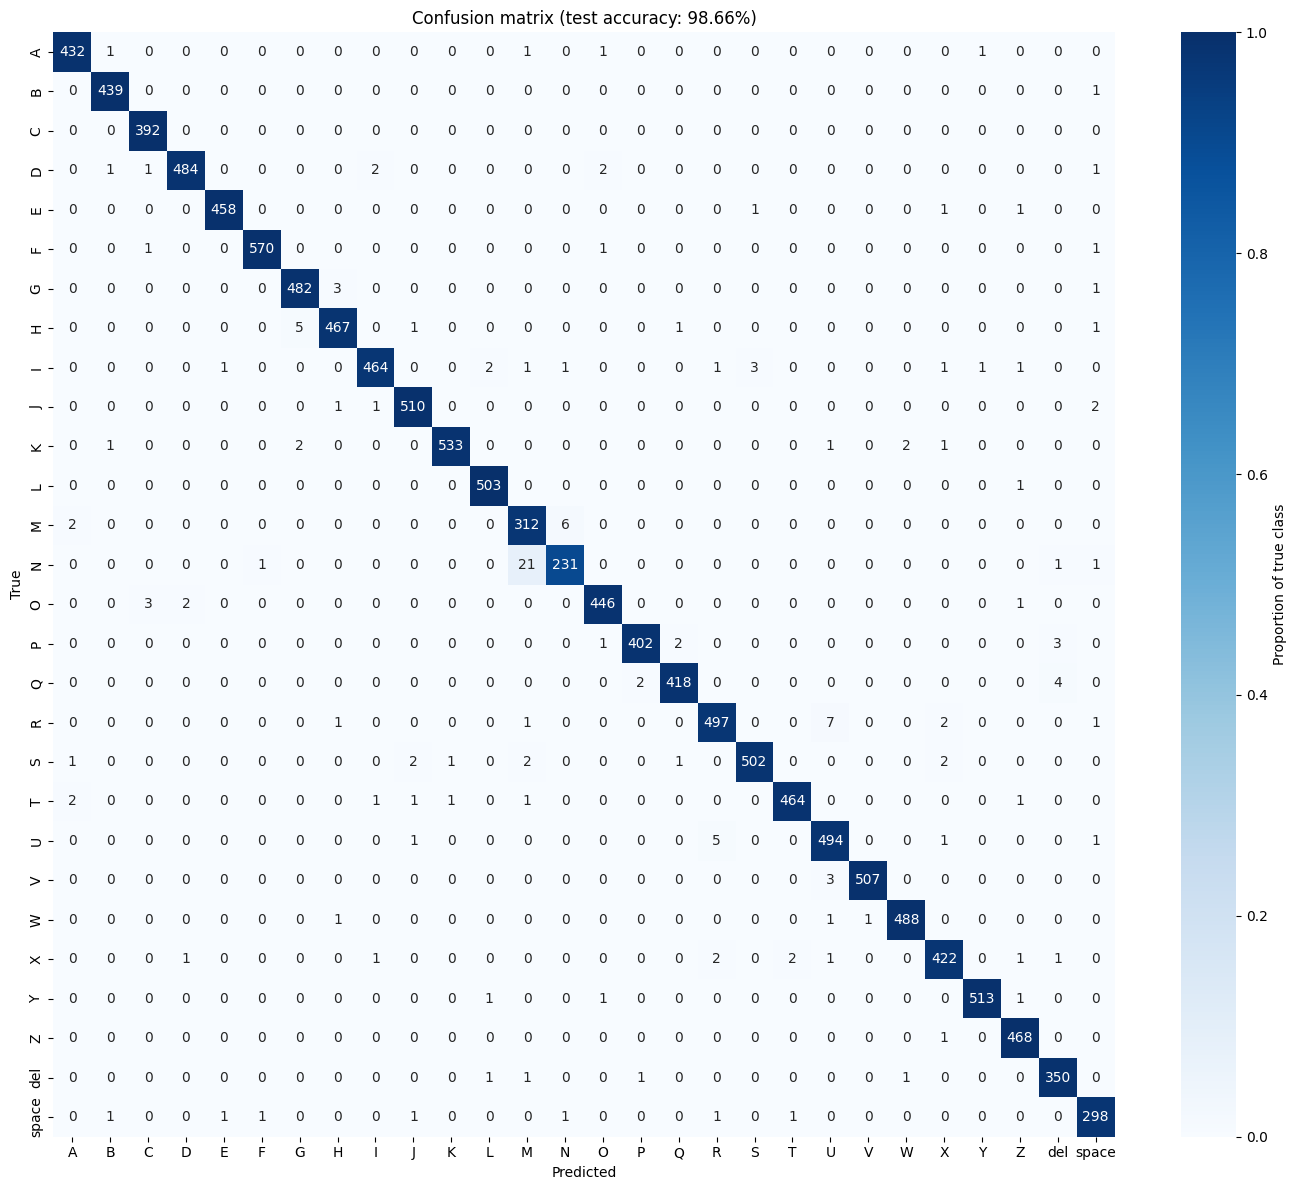

In [11]:
# Confusion matrix as a heatmap
cm = confusion_matrix(y_test, y_pred)

# Normalize per row so colors mean "% of true class predicted as col"
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_norm,
    annot=cm,            # raw counts in the cells
    fmt="d",
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cbar_kws={"label": "Proportion of true class"},
    ax=ax,
)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion matrix (test accuracy: {acc * 100:.2f}%)")
plt.tight_layout()
plt.show()

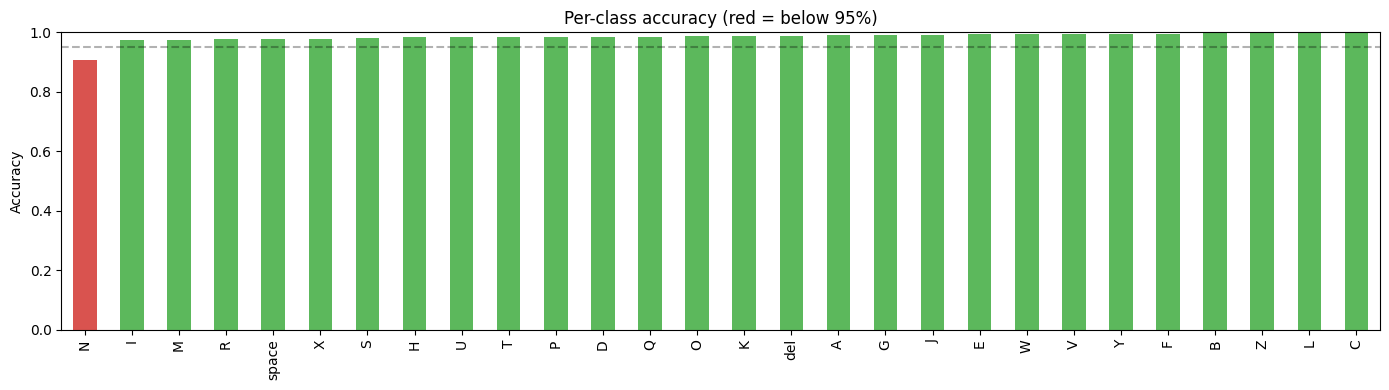

N        0.905882
I        0.974790
M        0.975000
R        0.976424
space    0.977049
X        0.979118
S        0.982387
H        0.983158
U        0.984064
T        0.985138
P        0.985294
D        0.985743
Q        0.985849
O        0.986726
K        0.987037
del      0.988701
A        0.990826
G        0.991770
J        0.992218
E        0.993492
W        0.993890
V        0.994118
Y        0.994186
F        0.994764
B        0.997727
Z        0.997868
L        0.998016
C        1.000000
Name: accuracy, dtype: float64

In [12]:
# Per-class accuracy, sorted worst-first — quick way to spot trouble classes
per_class_acc = pd.Series(
    cm.diagonal() / cm.sum(axis=1),
    index=le.classes_,
    name="accuracy",
).sort_values()

fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#d9534f" if a < 0.95 else "#5cb85c" for a in per_class_acc]
per_class_acc.plot(kind="bar", ax=ax, color=colors)
ax.set_title("Per-class accuracy (red = below 95%)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.0)
ax.axhline(0.95, color="black", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

per_class_acc

## 7. Feature importance (optional)

Which of the 63 landmark coordinates does XGBoost rely on most? Each
feature is `f{N}` where `N // 3` is the landmark index (0=wrist,
4=thumb tip, 8=index tip, 12=middle tip, 16=ring tip, 20=pinky tip)
and `N % 3` is the coordinate (0=x, 1=y, 2=z).

Mostly diagnostic — useful to confirm the model is using the fingertip
landmarks more than the wrist (which we normalized to zero, so it
shouldn't carry information).

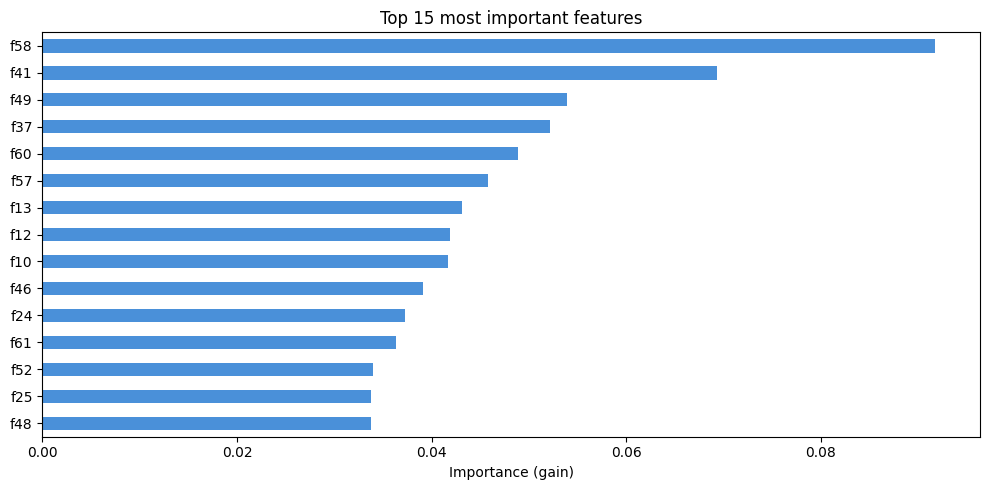

In [13]:
# Top-15 most important features
importance = pd.Series(
    clf.feature_importances_,
    index=feature_cols,
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
importance.head(15).plot(kind="barh", ax=ax, color="#4a90d9")
ax.invert_yaxis()
ax.set_title("Top 15 most important features")
ax.set_xlabel("Importance (gain)")
plt.tight_layout()
plt.show()

## 8. Save the model

Writes the trained model and label encoder to `models/`. These are
the same two files `predict.py` and `test_webcam.py` load.

In [14]:
# Save model + encoder
model_path = OUT_DIR / "asl_xgb.json"
encoder_path = OUT_DIR / "label_encoder.pkl"

clf.save_model(str(model_path))
joblib.dump(le, encoder_path)

print(f"Model:   {model_path}  ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"Encoder: {encoder_path}  ({encoder_path.stat().st_size / 1024:.1f} KB)")

Model:   ..\models\asl_xgb.json  (13599.5 KB)
Encoder: ..\models\label_encoder.pkl  (0.6 KB)


## Next steps

The model is saved. From here:

```cmd
python -m src.test_webcam
```

opens your webcam and runs live inference using the model you just trained.

To convert this notebook back to `train.py` once you're happy with the
hyperparameters, just copy the values from cell 9 into the `params`
dict in `train.py`.